# Chorus TF-IDF Song Recommender
Building off the inital TF-IDF recommender, this version takes a look at chorus only lyrics from songs. The previous full lyric recommender assumes that the entire songs text is equally useful for capturing similarity. But in practice, not every part of a song contributes the same way. Versus often contain specific narrative deaitls, scene setting, or one-off lines, while the chorus is usually the most repreated, memorable, and emotionally central part of the song. So by isolating chorus text, recommendation quality can be judged when the focus of the model is on the lyrical core of a teack rather than the full song. 

## 1. Imports & Setup

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from chorus_preprocessing import preprocess_chorus
from chorus_recommender import build_chorus_recommender, recommend_songs
from tfidf_recommender import (
    build_tfidf_recommender,
    recommend_songs as tfidf_recommend
)

pd.set_option('display.max_colwidth', 60)

## 2. Preprocess Chorus Data

In [2]:
chorus_df = preprocess_chorus(
    raw_lyrics_path='../data/raw/lyrics.csv',
    output_path='../data/processed/chorus_clean.csv'
)
chorus_df.head()

Dropped 213 songs flagged as prose/annotation content
Songs kept (chorus found):  1051/1928 (54.5%)
Songs skipped (no chorus):  877/1928 (45.5%)
Saved 1051 songs to ../data/processed/chorus_clean.csv


,track_id,track_name,artist,lyrics,chorus_text,processed_chorus,token_count
0,0qNnE0beu4OfHk8Txa3vGt,Soul Flower - Remix,The Pharcyde,"[Chorus]\nEe, ah, ooh, ah, ah, ee, ah, ooh, ah, ah\nEe, ...","Ee, ah, ooh, ah, ah, ee, ah, ooh, ah, ah\nEe, ah, ooh, a...",ee ah ooh ah ah ee ah ooh ah ah ee ah ooh ah ah ee ah oo...,60
1,7AHX0F99w4x23uSZihklZ6,My God,Tapir!,[Verse 1]\nWaking up with intuition\nGoing back to sleep...,But don't let it break you\nThere's no complications\nIt...,dont let break there complication imagination dont let b...,17
2,1KbpVvPiLAt1Wsh5gr2YKM,Take a Trip,TV Girl,"[Intro]\nTake, take, take a trip, take a trip back down\...",It's not something you can point to\nIt's not something ...,point hold heaven know heaven know happens world point h...,65
3,56s4IHGnJVGZYcdOVmC3eb,"I Love Life, Thank You",Mac Miller,"[Intro]\nAlright then, bitch\nHa, ya\nUh\nA million moth...","Ayo, this where the hook be\nBut I ain't got no hook, yo...",ayo hook aint got hook pussy said hook bitch aint got fu...,26
4,5XufqHphZkJhIkc5wlEST7,Soft Rock Band,Good Morning,[Intro]\nWell I played time in exile\nAnd the weather it...,"Oh, I might have seen it all\nBut I know, oh, there's st...",oh seen know oh there oh oh seen know there yeah know se...,26


In [3]:
# Corpus summary
n_total = len(chorus_df)

print(f"Total songs in chorus corpus: {n_total}")
print()
print("Token count distribution (chorus only):")
print(chorus_df['token_count'].describe().round(1))

Total songs in chorus corpus: 1051

Token count distribution (chorus only):
count    1051.0
mean       50.8
std        36.6
min        10.0
25%        26.5
50%        41.0
75%        65.0
max       507.0
Name: token_count, dtype: float64


## 3. Chorus Extraction Inspection

In [4]:
def inspect_song(track_name, artist=None):
    matches = chorus_df[chorus_df['track_name'].str.lower() == track_name.lower()]
    if artist:
        matches = matches[matches['artist'].str.lower() == artist.lower()]
    if matches.empty:
        print(f"'{track_name}' not found.")
        return
    row = matches.iloc[0]
    print(f"Track:       {row['track_name']} — {row['artist']}")
    print(f"Token count: {row['token_count']}")
    print(f"\nRaw chorus text:\n{str(row['chorus_text'])[:600]}")
    print(f"\nProcessed:   {str(row['processed_chorus'])[:300]}")

# Check each of your 4 seed songs
inspect_song('Iron Clad Lou',  'Hum')
print('\n' + '='*70 + '\n')
# Had to switch this seed because it wasn't found in the chorus corpus
inspect_song('Everybody Loves The Sunshine',     'Roy Ayers Ubiquity')
print('\n' + '='*70 + '\n')
# Had to switch this seed because it wasn't found in the chorus corpus
inspect_song('Volare', 'Gipsy Kings')
print('\n' + '='*70 + '\n')
inspect_song('House Money',    'Baby Keem')
print('\n' + '='*70 + '\n')

Track:       Iron Clad Lou — Hum
Token count: 16

Raw chorus text:
I win, I win, I win
It sure gets lonely at the top
It sure feels weird, you're falling out
It sure gets lonely at the top
I win, I win

Processed:   win win win sure get lonely sure feel weird youre falling sure get lonely win win


Track:       Everybody Loves The Sunshine — Roy Ayers Ubiquity
Token count: 40

Raw chorus text:
My life, my life, my life, my life
In the sunshine
Everybody loves the sunshine
Sunshine
Everybody loves the sunshine
Sunshine
Folks get down in the sunshine (Oooh)
Sunshine (Yeeea-ah)
Folks get brown in the sunshine
My life, my life, my life, my life
In the sunshine
Everybody loves the sunshine
Sunshine
Everybody loves the sunshine
Sunshine
Folks get down in the sunshine
Sunshine
Folks get brown in the sunshine

Processed:   life life life life sunshine everybody love sunshine sunshine everybody love sunshine sunshine folk sunshine oooh sunshine yeeeaah folk brown sunshine life life life life su

## 4. Full Lyrics vs Chorus Only Tokens

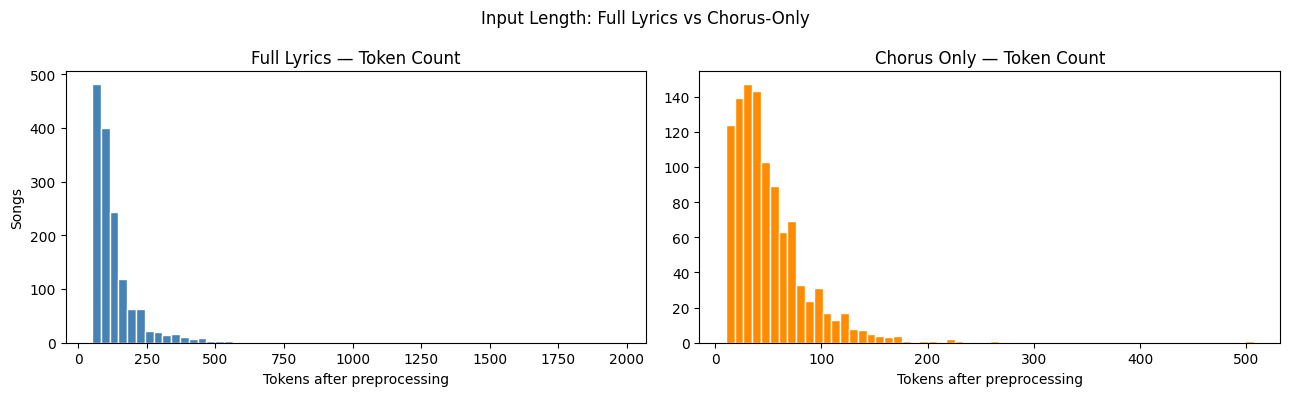

Full lyrics token stats:
count    1502.0
mean      145.2
std       181.9
min        50.0
25%        76.0
50%       102.0
75%       147.0
max      1975.0
Name: token_count, dtype: float64

Chorus-only token stats:
count    1051.0
mean       50.8
std        36.6
min        10.0
25%        26.5
50%        41.0
75%        65.0
max       507.0
Name: token_count, dtype: float64


In [5]:
full_df = pd.read_csv('../data/processed/lyrics_clean.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

axes[0].hist(full_df['token_count'],   bins=60, color='steelblue',  edgecolor='white')
axes[0].set_title('Full Lyrics — Token Count')
axes[0].set_xlabel('Tokens after preprocessing')
axes[0].set_ylabel('Songs')

axes[1].hist(chorus_df['token_count'], bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Chorus Only — Token Count')
axes[1].set_xlabel('Tokens after preprocessing')

plt.suptitle('Input Length: Full Lyrics vs Chorus-Only')
plt.tight_layout()
plt.show()

print("Full lyrics token stats:")
print(full_df['token_count'].describe().round(1))
print("\nChorus-only token stats:")
print(chorus_df['token_count'].describe().round(1))

A much lower token count for the processed chorus, which is to be expected. 

## 5. Recommenders

In [6]:
# Chorus model
chorus_df_model, chorus_tfidf, chorus_sim, chorus_vec = build_chorus_recommender(
    '../data/processed/chorus_clean.csv'
)

# Full-lyric TF-IDF baseline
full_df_model, full_tfidf, full_sim = build_tfidf_recommender(
    '../data/processed/lyrics_clean.csv'
)

print(f"Chorus corpus size:    {len(chorus_df_model)} songs")
print(f"Full lyric corpus:     {len(full_df_model)} songs")
print(f"Chorus TF-IDF matrix:  {chorus_tfidf.shape}")
print(f"Full TF-IDF matrix:    {full_tfidf.shape}")

Chorus corpus size:    1051 songs
Full lyric corpus:     1502 songs
Chorus TF-IDF matrix:  (1051, 2922)
Full TF-IDF matrix:    (1502, 10000)


## 6. Recommendation Comparison

In [7]:
def compare_models(seed_title, seed_artist=None, k=10):
    """Print full-lyric TF-IDF and chorus-only recommendations side by side."""
    try:
        full_recs = tfidf_recommend(
            full_df_model, full_sim,
            seed_title=seed_title, seed_artist=seed_artist, k=k
        ).rename(columns={'similarity': 'full_score'})
    except ValueError:
        print(f"[NOT FOUND in full corpus] '{seed_title}'")
        return None, None

    try:
        chorus_recs = recommend_songs(
            chorus_df_model, chorus_sim,
            seed_title=seed_title, seed_artist=seed_artist, k=k
        ).rename(columns={'similarity': 'chorus_score'})
    except ValueError:
        print(f"[NOT FOUND in chorus corpus] '{seed_title}'")
        return None, None

    full_recs.index   += 1
    chorus_recs.index += 1

    print(f"\nSeed: '{seed_title}'{' by ' + seed_artist if seed_artist else ''}")
    print(f"{'Rank':<5} {'── Full Lyrics ──':<46} {'── Chorus Only ──':<46}")
    print('-' * 97)
    for i in range(1, k + 1):
        f = full_recs.loc[i]
        c = chorus_recs.loc[i]
        f_str = f"{f['track_name'][:28]} — {f['artist'][:12]} ({f['full_score']:.3f})"
        c_str = f"{c['track_name'][:28]} — {c['artist'][:12]} ({c['chorus_score']:.3f})"
        print(f"{i:<5} {f_str:<46} {c_str:<46}")

    return full_recs, chorus_recs

In [8]:
# --- Grunge ---
full_grunge, chorus_grunge = compare_models('Iron Clad Lou', seed_artist='Hum')


Seed: 'Iron Clad Lou' by Hum
Rank  ── Full Lyrics ──                              ── Chorus Only ──                             
-------------------------------------------------------------------------------------------------
1     Stand up and Win — Spymob (0.144)              Faxing It In — Smushie (0.248)                
2     Never Lonely — Space Mounta (0.135)            The Great Salt Lake — Band of Hors (0.199)    
3     Downtown — Varsity (0.123)                     Belief — John Mayer (0.194)                   
4     Rain — World's Expe (0.119)                    Weird Fishes / Arpeggi — Radiohead (0.183)    
5     Faxing It In — Smushie (0.112)                 There’d Better Be A Mirrorba — Arctic Monke (0.173)
6     Hippies — flipturn (0.109)                     UFO — The Juice Is (0.171)                    
7     Warmest Part of the Winter — Voxtrot (0.106)   Arabella — Arctic Monke (0.168)               
8     2023 — Blue Rain Bo (0.105)                    Alright — Supe

Similarity scores are higher on averarge in the chorus only version, but not a single song on the list is a grunge song. This further emphasizes the point that grunge music is better defined by a hardcore rock sound than the lyrical message. 

In [ ]:
# --- Soul ---
full_soul, chorus_soul = compare_models(
    'Everybody Loves The Sunshine', seed_artist= 'Roy Ayers Ubiquity')


Seed: 'Everybody Loves The Sunshine' by Roy Ayers Ubiquity
Rank  ── Full Lyrics ──                              ── Chorus Only ──                             
-------------------------------------------------------------------------------------------------
1     Holy Moly, Rock n' Rolly, Gu — LAZY GHOST (0.328) Sunshine Of Your Love — Cream (0.225)         
2     Sunshine Of Your Love — Cream (0.153)          Strawberry Letter 23 — Shuggie Otis (0.212)   
3     Sir Duke — Stevie Wonde (0.149)                You Only Live Once — The Strokes (0.189)      
4     Ain't No Sunshine — Bill Withers (0.137)       Sunday Best — Surfaces (0.179)                
5     Sunday Best — Surfaces (0.130)                 Maybelle — Ida (0.152)                        
6     You And Your Folks, Me And M — Funkadelic (0.129) Hesitation — Hot Flash He (0.132)             
7     Sunshine — The Velvet C (0.127)                Mr. Jones — Counting Cro (0.128)              
8     You Only Live Once — The Strok

Like in the grunge test, the chorus only similarity scores were higher on average. However, only one soul song makes the list: Starberry Letter 23. The full lyric recommender found two soul songs: "Sir Duke" and "Ain't No Sunshine." Overall, both recommenders are sturggling with soul music. 

In [21]:
# --- Latin ---
full_latin, chorus_latin = compare_models(
    'Heaven Knows', seed_artist= '54 Ultra'
)


Seed: 'Heaven Knows' by 54 Ultra
Rank  ── Full Lyrics ──                              ── Chorus Only ──                             
-------------------------------------------------------------------------------------------------
1     A Dozen Roses — Braid (0.334)                  Lapdance — N.E.R.D (0.335)                    
2     Sweetest Thing on This Side  — Papa Bear &  (0.309) Ann Don't Cry — Pavement (0.314)              
3     Pennies From Heaven — Louis Prima (0.260)      Jerk It Out — Caesars (0.257)                 
4     The Scoop On Heaven — Mac Miller (0.256)       Cause = Time — Broken Socia (0.252)           
5     For Martha — The Smashing (0.247)              You Only Live Once — The Strokes (0.220)      
6     Where Are You — 54 Ultra (0.194)               Fade — Knowmadic (0.215)                      
7     Cool God — Jack Symes (0.176)                  I Don't Mind — The Shed (0.202)               
8     Take a Trip — TV Girl (0.172)                  Bound For 

The seed song for Latin music had to change, because the original see was removed in chorus preprocessing. For this seed, both recomemnders performed quite similar but the chorus only recommender did better on average. Yet the same lack of genre representation seen in the first two tests carries over here. Both full lyric model and chorus model had zero latin represnetation in its top-10 most semantically similar songs. 

In [22]:
# --- Hip-hop ---
full_hiphop, chorus_hiphop = compare_models(
    'House Money', seed_artist='Baby Keem')


Seed: 'House Money' by Baby Keem
Rank  ── Full Lyrics ──                              ── Chorus Only ──                             
-------------------------------------------------------------------------------------------------
1     Jesus Is The One (I Got Depr — Zack Fox (0.441) Blood On Me — Sampha (0.235)                  
2     Can You Rap Like Me? — Trippie Redd (0.363)    The Killing Moon — Echo & the B (0.202)       
3     Hit Bout It — Lil Yachty (0.329)               Tried And True — Ween (0.201)                 
4     Blood On Me — Sampha (0.321)                   fafo — Zack Fox (0.181)                       
5     REEL IT IN — Aminé (0.286)                     I Love Life, Thank You — Mac Miller (0.167)   
6     trademark usa — Baby Keem (0.272)              Watermelon — John + Jane  (0.146)             
7     JayJay-Z — Zelooperz (0.266)                   Stop Whispering — Radiohead (0.133)           
8     Fresh Prince Of Utah — YoungBoy Nev (0.262)    (Don't Fear) T

Finally an interesting result from the chorus model! Surprisingly, the chorus only recommender performed significantly worse than the full lyric recommender. The full lyric model recommendations are all in the hip-hop genre, whereas the chorus only recommender only has five hip-hop recommendations. I hypothesize that the reason the chrous recommender is worse at recognizing hip-hop songs is because the similarity found in the full lyric model is primarily due to adlibs and explicative not found frequently in the chorus. Choruses are the heart of a song's message, and based on the chorus recommender, we can see that those messages vary. 

## 7. Overlap: Full Lyrics vs Chorus

In [23]:
def overlap_stats(full_recs, chorus_recs, label):
    if full_recs is None or chorus_recs is None:
        print(f"{label}: skipped (not found)\n")
        return
    full_set   = set(zip(full_recs['track_name'],   full_recs['artist']))
    chorus_set = set(zip(chorus_recs['track_name'], chorus_recs['artist']))
    shared   = full_set & chorus_set
    jaccard  = len(shared) / len(full_set | chorus_set)
    print(f"{label}")
    print(f"  Shared songs:   {len(shared)}/10")
    print(f"  Jaccard score:  {jaccard:.2f}")
    if shared:
        print(f"  Overlap:        {', '.join([s[0] for s in shared])}")
    print()

overlap_stats(full_grunge,  chorus_grunge,  'Grunge  (Iron Clad Lou)')
overlap_stats(full_soul,    chorus_soul,    'Soul    (Everybody Loves the Sunshine)')
overlap_stats(full_latin,   chorus_latin,   'Latin   (Heaven Knows)')
overlap_stats(full_hiphop,  chorus_hiphop,  'Hip-hop (House Money)')

Grunge  (Iron Clad Lou)
  Shared songs:   1/10
  Jaccard score:  0.05
  Overlap:        Faxing It In

Soul    (Everybody Loves the Sunshine)
  Shared songs:   4/10
  Jaccard score:  0.25
  Overlap:        Sunshine Of Your Love, You Only Live Once, Sunday Best, You And Your Folks, Me And My Folks

Latin   (Heaven Knows)
  Shared songs:   0/10
  Jaccard score:  0.00

Hip-hop (House Money)
  Shared songs:   1/10
  Jaccard score:  0.05
  Overlap:        Blood On Me



Extremely low similarity and overlap between the two models. This tells us that a songs message and overall lyrical composition explain different aspect, which is totally expected.

## 8. Similarity Score Distribution: Full vs Chorus

Songs in both corpora: 974


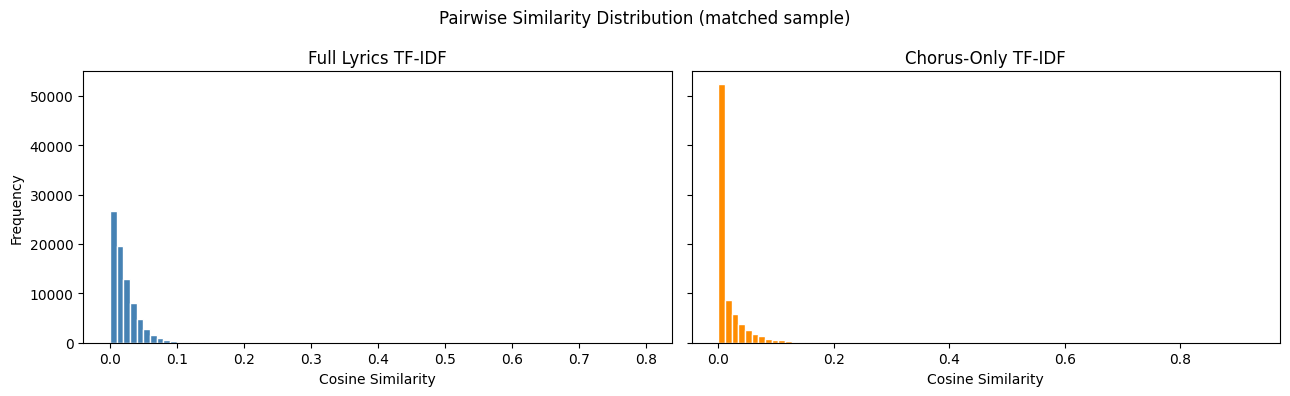

Full lyrics:  mean=0.0226  median=0.0162  >0.1: 1.2%  >0.3: 0.1%
Chorus only:  mean=0.0168  median=0.0000  >0.1: 2.8%  >0.3: 0.1%


In [24]:
# Use only songs present in both corpora for a fair comparison
shared_songs = set(zip(full_df_model['track_name'], full_df_model['artist'])) & \
               set(zip(chorus_df_model['track_name'], chorus_df_model['artist']))
print(f"Songs in both corpora: {len(shared_songs)}")

sample_size = min(400, len(shared_songs))
rng = np.random.default_rng(42)

# Get indices in each DataFrame for the shared sample
shared_list = list(shared_songs)
sample_songs = [shared_list[i] for i in rng.choice(len(shared_list), sample_size, replace=False)]

def get_indices(df, song_list):
    idx = []
    for name, artist in song_list:
        match = df[(df['track_name'] == name) & (df['artist'] == artist)]
        if not match.empty:
            idx.append(match.index[0])
    return idx

full_idx   = get_indices(full_df_model,   sample_songs)
chorus_idx = get_indices(chorus_df_model, sample_songs)

n = min(len(full_idx), len(chorus_idx))
full_sample   = full_sim[np.ix_(full_idx[:n],   full_idx[:n])]
chorus_sample = chorus_sim[np.ix_(chorus_idx[:n], chorus_idx[:n])]

full_upper   = full_sample[np.triu_indices(n, k=1)]
chorus_upper = chorus_sample[np.triu_indices(n, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
axes[0].hist(full_upper,   bins=80, color='steelblue',  edgecolor='white')
axes[0].set_title('Full Lyrics TF-IDF')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Frequency')

axes[1].hist(chorus_upper, bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Chorus-Only TF-IDF')
axes[1].set_xlabel('Cosine Similarity')

plt.suptitle('Pairwise Similarity Distribution (matched sample)')
plt.tight_layout()
plt.show()

for label, arr in [('Full lyrics', full_upper), ('Chorus only', chorus_upper)]:
    print(f"{label}:  mean={arr.mean():.4f}  median={np.median(arr):.4f}  "
          f">0.1: {(arr > 0.1).mean()*100:.1f}%  >0.3: {(arr > 0.3).mean()*100:.1f}%")

I'm surprised the chorus only recommender has lower mean similarity overall considering the average similarity scores in the top-10 where higher in three of the four tests for the chorus only recommender. Maybe melodic non-lexical vocables and adlibs are carrying the similarity scores in the full lyric model. Stop words were removed in preprocessing so basic similarities like that are not a contributing factor. 

## 9. Observations & Notes